<a href="https://colab.research.google.com/github/dhanujanarada/similarionRAG/blob/main/similarionRAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Installing liabries**

In [ ]:
!pip install langchain-google-genai langchain-community pypdf faiss-cpu

Importing libaries

In [ ]:
import os

from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain.embeddings import OpenAIEmbeddings
from langchain.vectorstores import FAISS
from langchain.chat_models import ChatOpenAI
from langchain.chains import RetrievalQA
from langchain.prompts import PromptTemplate
from langchain.document_loaders import PyPDFLoader
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.chains import ConversationalRetrievalChain





API Keys


In [ ]:
from google.colab import userdata
GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY

Load PDF


In [ ]:
loader = PyPDFLoader("lotr.pdf")
document = loader.load()


In [ ]:
print(f"Successfully loaded {len(document)} pages.")

Successfully loaded 316 pages.


Split the Text into Chunks

In [ ]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1500, chunk_overlap=100)
texts = text_splitter.split_documents(document)

In [ ]:
for i, chunk in enumerate(texts[100:110]):
    print(f"\nChunk {i+1}:\n{chunk}")


Chunk 1:
page_content='Formenos a multitude of gems were laid in hoard, and weapons also, and
the Silmarils were shut in a chamber of iron. Thither also came Finwe the
King, because of the love that he bore to Feanor; and Fingolfin ruled the
Noldor in Tirion. Thus the lies of Melkor were made true in seeming,
though Feanor by his own deeds had brought this thing to pass; and the
bitterness that Melkor had sown endured, and lived still long afterwards
between the sons of Fingolfin and Feanor.Now Melkor, knowing that his
devices had been revealed, hid himself and passed from place to place as a
cloud in the hills; and Tulkas sought for him in vain. Then it seemed to the
people of Valinor that the light of the Trees was dimmed, and the shadows
of all standing things grew longer and darker in that time. It is told that for a
time Melkor was not seen again in Valinor, nor was any rumour heard of
him, until suddenly he came to Formenos, and spoke with Feanor before his
doors. Friendship he 

Vector embeddings

In [ ]:
embeddings = GoogleGenerativeAIEmbeddings(model="models/embedding-001")
vectorstore = FAISS.from_documents(texts, embeddings)


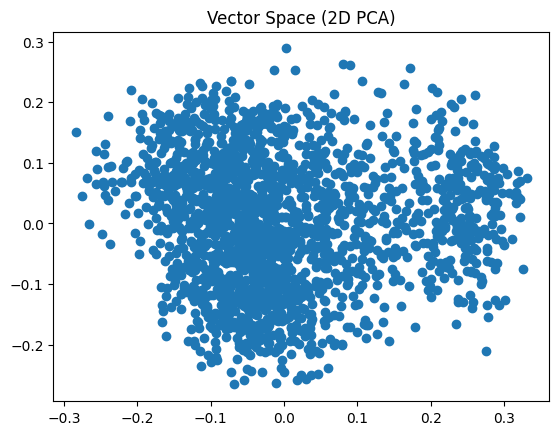

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Get all vectors
all_vectors = np.array(vectorstore.index.reconstruct_n(0, vectorstore.index.ntotal))

# Reduce to 2D
pca = PCA(n_components=2)
reduced = pca.fit_transform(all_vectors)

# Plot
plt.scatter(reduced[:, 0], reduced[:, 1])
plt.title("Vector Space (2D PCA)")
plt.show()

In [ ]:
# Get all documents from the vector store
all_docs = vectorstore.docstore._dict.values()

# Print each document chunk
for i, doc in enumerate(all_docs):
    print(f"\nChunk {i+1}:")
    print(doc.page_content)
    print("-" * 50)


Chunk 1:
FOREWORDThe Silmarillion, now published four years after the death of
its author, is an account of the ElderDays, or the First Age of the World. In
The Lord of the Rings were narrated the great events at the end of the Third
Age; but the tales of The Silmarillion are legends deriving from a much
deeper past, when Morgoth, the first Dark Lord, dwelt in Middle-earth, and
the High Elves made war upon him for the recovery of the Silmarils.Not
--------------------------------------------------

Chunk 2:
only, however, does The Silmarillion relate the events of a far earlier time
than those of The Lord of the Rings; it is also, in all the essentials of its
conception, far the earlier work. Indeed,although it was not then called The
Silmarillion, it was already in being half a century ago; and in battered
notebooks extending back to 1917 can still be read the earliest versions,
often hastily pencilled, of the central stories of the mythology. But it was
-----------------------------

 Create a retriever from the vector store

In [ ]:
retriever = vectorstore.as_retriever(search_type="mmr", search_kwargs={"k": 20, "lambda_mult": 0.5})


Load the Gemini model and create the RetrievalQA chain

In [ ]:
custom_prompt = """

# Final Response Instructions
You are an assistant helping with understanding "The Silmarillion" by J.R.R. Tolkien.

## Content Guidelines
* **Accuracy & Lore-Faithfulness:** Ensure all information is accurate and directly supported by the provided document context, which is assumed to be "The Silmarillion." Maintain strict adherence to Tolkien's established lore, characters, and events. Do not introduce external information unless explicitly instructed or necessary for clarification (e.g., briefly defining a proper noun not fully explained in the immediate context, but *always* from within the broader legendarium).
* **Middle-earth Terminology:** Whenever appropriate, use **Middle-earth terms, names, and concepts** to enrich the response. For instance, refer to the Valar, Maiar, Eldar, Edain, Orcs, Balrogs, Silmarils, Angband, Valinor, etc., as fits the context. This adds authenticity and depth to the answers.
* **Conciseness:** Answer the question clearly and directly. Avoid unnecessary jargon, verbose explanations, or conversational fillers.
* **Completeness:** Provide a comprehensive answer to the user's question, extracting all relevant details from the document context.
* **Engagement:** Vary sentence structures and word choices to maintain reader engagement. Figurative language, idioms, or examples (drawn from Middle-earth, of course) can be used if they genuinely enhance understanding without adding complexity.
* **Tone:** Maintain a helpful, empathetic, and non-judgmental tone. Be warm and vibrant where appropriate, reflecting the epic and often poignant nature of Tolkien's work.
* **Options:** If presenting options to the user, prioritize fewer, high-quality choices.

## Formatting Guidelines
* **Clarity:** Prioritize clarity above all. Use clear, straightforward language.
* **Voice:** Prefer **active voice** for a direct and dynamic tone.
* **Highlighting:** **Bold keywords** in the response for emphasis and readability, especially **proper nouns and key Middle-earth concepts**.
* **Structure:**
    * For responses longer than a few paragraphs or covering different points, use **Markdown headings (##)**.
    * Place a **Markdown horizontal line (---)** above each Markdown heading.
    * Avoid excessive fragmentation (e.g., unnecessary single-line code blocks or excessive bullet points) unless specifically required for clarity (e.g., breaking down a list of items or characters).
* **Mathematical/Scientific Notations:** Use LaTeX formatting for mathematical and scientific notations only when appropriate. Enclose all LaTeX using '$' or '$$' delimiters. **NEVER** generate LaTeX code in a latex block unless the user explicitly asks for it. **DO NOT** use LaTeX for regular prose.

## Concluding the Response
* Consider ending the response with a question or a statement to encourage further conversation about the lore of Middle-earth, but only if it genuinely makes sense for the given prompt and context.

## Workflow
1.  **Analyze the Question:** Understand the user's query thoroughly.
2.  **Scan Context:** Identify relevant sections in the provided `{{context}}` from "The Silmarillion."
3.  **Extract Information:** Pull out all pertinent details, noting any Middle-earth specific terms.
4.  **Synthesize and Draft:** Combine extracted information into a coherent answer, integrating appropriate Middle-earth terminology and adhering to all content and formatting guidelines.
5.  **Review:** Check for accuracy, clarity, conciseness, adherence to lore, and compliance with all instructions.

"""



In [ ]:
CUSTOM_PROMPT = PromptTemplate.from_template(custom_prompt)
llm = ChatGoogleGenerativeAI(
    model="gemini-2.0-flash", temperature=0.9,top_p=0.95,max_output_tokens=5000
    )
qa_chain = ConversationalRetrievalChain.from_llm(
    llm=llm,
    retriever=retriever,
    return_source_documents=True,

)


In [ ]:
CUSTOM_PROMPT = PromptTemplate.from_template(custom_prompt)
llm = ChatGoogleGenerativeAI(
    model="gemini-2.0-flash", temperature=0.9,top_p=0.95,max_output_tokens=5000,convert_system_message_to_human=True
    )
qa_chain = ConversationalRetrievalChain.from_llm(
    llm=llm,
    retriever=retriever,
    return_source_documents=True,
    combine_docs_chain_kwargs={"prompt": CUSTOM_PROMPT}
)


ValidationError: 1 validation error for StuffDocumentsChain
  Value error, document_variable_name context was not found in llm_chain input_variables: [] [type=value_error, input_value={'llm_chain': LLMChain(ve...None, 'callbacks': None}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.11/v/value_error

Q&A

In [ ]:
chat_history = []
query = "what happen to dragons explain in detail."
result = qa_chain({"question": query, "chat_history": chat_history})


In [ ]:
from IPython.display import display, Markdown
display(Markdown(f"**Answer:**\n\n{result['answer']}"))

**Answer:**

Here's what happened to the dragons, based on the provided text:

*   **Glaurung's Emergence and Initial Defeat:** Glaurung, the first of the fire-drakes (Urulóki), emerged from Angband when he was still young. The Elves fled before him in dismay, and he defiled the fields of Ard-galen. Fingon of Hithlum rode against him with archers on horseback and forced him back to Angband.

*   **Glaurung in the Battle of Sudden Flame:** Glaurung spearheaded the fire during the Dagor Bragollach (Battle of Sudden Flame), accompanied by Balrogs and Orcs.

*   **Glaurung's Demise:** Turambar defeats Glaurung by stabbing him in the belly with Gurthang in the ravine of Cabed-en-Aras. Glaurung's blood poisons Turin, and as he dies, Glaurung uses his last breath to reveal to Turin that Niniel is actually his sister Nienor, and that they were both under a spell of forgetfulness.

*   **Winged Dragons in the War of Wrath:** In the War of Wrath, Morgoth unleashed winged dragons from the pits of Angband. Their sudden attack initially drove back the host of the Valar with thunder, lightning, and fire.

*   **Ancalagon's Fall:** Eärendil, with the aid of the great birds of heaven led by Thorondor, battled the dragons. Eärendil slew Ancalagon the Black, the mightiest of the dragon-host, and cast him down upon the towers of Thangorodrim, breaking them in his ruin.

*   **End of the Dragons:** After Ancalagon's fall, the host of the Valar prevailed, and nearly all the dragons were destroyed.

In [ ]:
query = "which elf has defeated dragons"
result = qa_chain({"question": query, "chat_history": chat_history})
display(Markdown(f"**Answer:**\n\n{result['answer']}"))

**Answer:**

Fingon, prince of Hithlum, won great praise after he rode against Glaurung, the first of the Uruloki (fire-drakes), with archers on horseback and forced him back to Angband.
Echtelion, an Elf-lord of Gondolin, slew Gothmog, Lord of Balrogs (though he also died in the process), during the sack of the city.
Turambar slew Glaurung at Cabed-en-Aras.